    # Cattle Average Daily Gain Prediction with a Deep Neural Network

Estimate **average daily gain (ADG, kg/day)** from the `cattle_dataset.csv` dataset.

target variable: `adg_kg_day`.

# 1. Ambient configuration

## 1.1. Import packages

In [1]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1.2. GPU check

In [2]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device Name:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA is not available.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 92000
Device Name: NVIDIA GeForce RTX 5070
Device: cuda


# 2. Exploratory Data Analysis

## 2.1. Load data

In [3]:
DATA_PATH = "data/cattle_dataset_2.csv"
TARGET = "adg_kg_day"
LEAKAGE = "days_on_pasture" 

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

df = pd.read_csv(DATA_PATH)
if "origem" in df.columns:           # drop tag column if present
    df = df.drop(columns=["origem"])
df.head()

,initial_weight_kg,age_days,sex_male,bos_indicus_proportion_pct,supplement_amount_kg_day,supplement_crude_protein_pct,supplement_metabolizable_energy,supplementation_frequency_days_week,forage_crude_protein_pct,forage_digestibility_pct,days_on_pasture,paddock_rotation,transport_stress,mean_temperature_c,accumulated_rainfall_mm,days_since_health_event,health_event_duration_days,recent_vaccination,recent_deworming,adg_kg_day
0,185,620,0,50.0,0.248,30,2.0,7,10.42,61.2,381,1,1,29.0,47.8,0,0,0,0,0.330709
1,168,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.328889
2,153,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.317778
3,130,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.468889
4,156,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.342222


In [4]:
const_cols = [c for c in df.columns if df[c].nunique() == 1]
num_cols = [c for c in df.select_dtypes("number").columns if c not in const_cols]
bin_cols = [c for c in num_cols if set(df[c].dropna().unique()) <= {0, 1}]
cat_cols = [c for c in num_cols
            if c not in bin_cols and c != TARGET and df[c].nunique() <= 6]
cont_cols = [c for c in num_cols
             if c not in bin_cols and c not in cat_cols and c != TARGET]

print("Constant :", const_cols)
print("Continuous:", cont_cols)
print("Categorical:", cat_cols)
print("Binary   :", bin_cols)

Constant : ['sex_male', 'supplementation_frequency_days_week', 'paddock_rotation', 'recent_vaccination', 'recent_deworming']
Continuous: ['initial_weight_kg', 'age_days', 'supplement_amount_kg_day', 'days_on_pasture', 'mean_temperature_c', 'accumulated_rainfall_mm']
Categorical: ['bos_indicus_proportion_pct', 'supplement_crude_protein_pct', 'supplement_metabolizable_energy', 'forage_crude_protein_pct', 'forage_digestibility_pct', 'days_since_health_event', 'health_event_duration_days']
Binary   : ['transport_stress']


## 2.2. Overview

In [5]:
print(f"Samples: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(),
    "missing": df.isna().sum(),
})
overview

Samples: 494
Variables: 20


,dtype,unique,missing
initial_weight_kg,int64,183,0
age_days,int64,127,0
sex_male,int64,1,0
bos_indicus_proportion_pct,float64,4,0
supplement_amount_kg_day,float64,284,0
supplement_crude_protein_pct,int64,2,0
supplement_metabolizable_energy,float64,2,0
supplementation_frequency_days_week,int64,1,0
forage_crude_protein_pct,float64,6,0
forage_digestibility_pct,float64,6,0


## 2.3. Target variable distribution

count    494.000
mean       0.341
std        0.171
min       -0.698
25%        0.284
50%        0.345
75%        0.412
max        1.785
skewness: 1.16


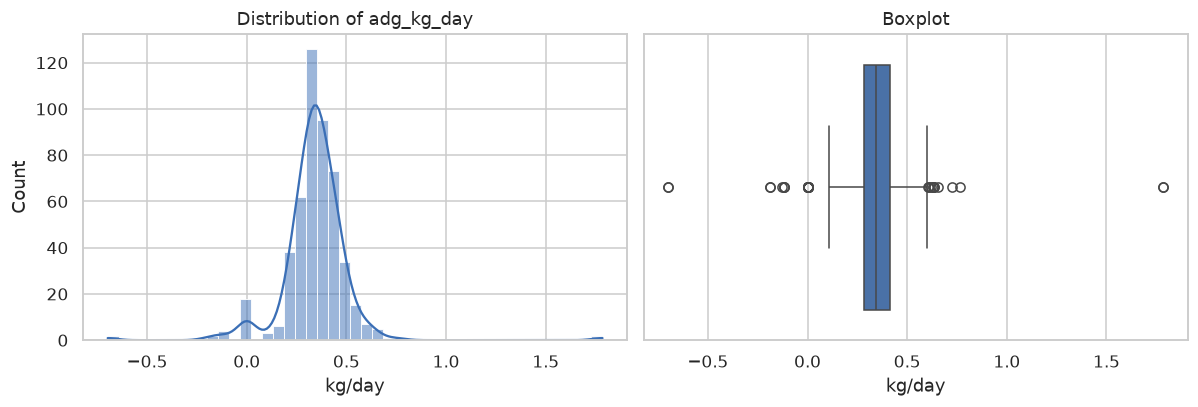

In [6]:
print(df[TARGET].describe().round(3).to_string())
print(f"skewness: {df[TARGET].skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(df[TARGET], kde=True, ax=ax[0], color="#3b6fb6")
ax[0].set_title(f"Distribution of {TARGET}"); ax[0].set_xlabel("kg/day")
sns.boxplot(x=df[TARGET], ax=ax[1], color="#3b6fb6")
ax[1].set_title("Boxplot"); ax[1].set_xlabel("kg/day")
plt.tight_layout(); plt.show()

## 2.4. Distributions of continuous variables

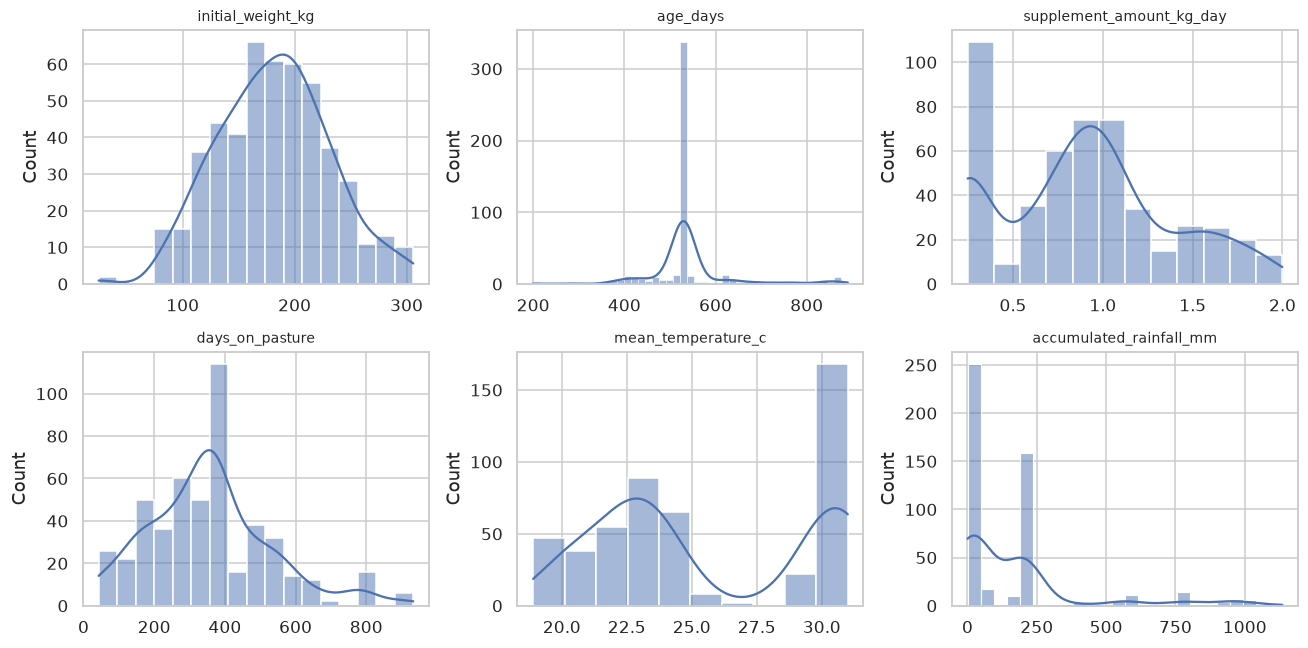

In [7]:
n = len(cont_cols); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3 * nrow))
axes = np.array(axes).reshape(-1)
for i, c in enumerate(cont_cols):
    sns.histplot(df[c], kde=True, ax=axes[i])
    axes[i].set_title(c, fontsize=9); axes[i].set_xlabel("")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 2.5. Correlation matrix

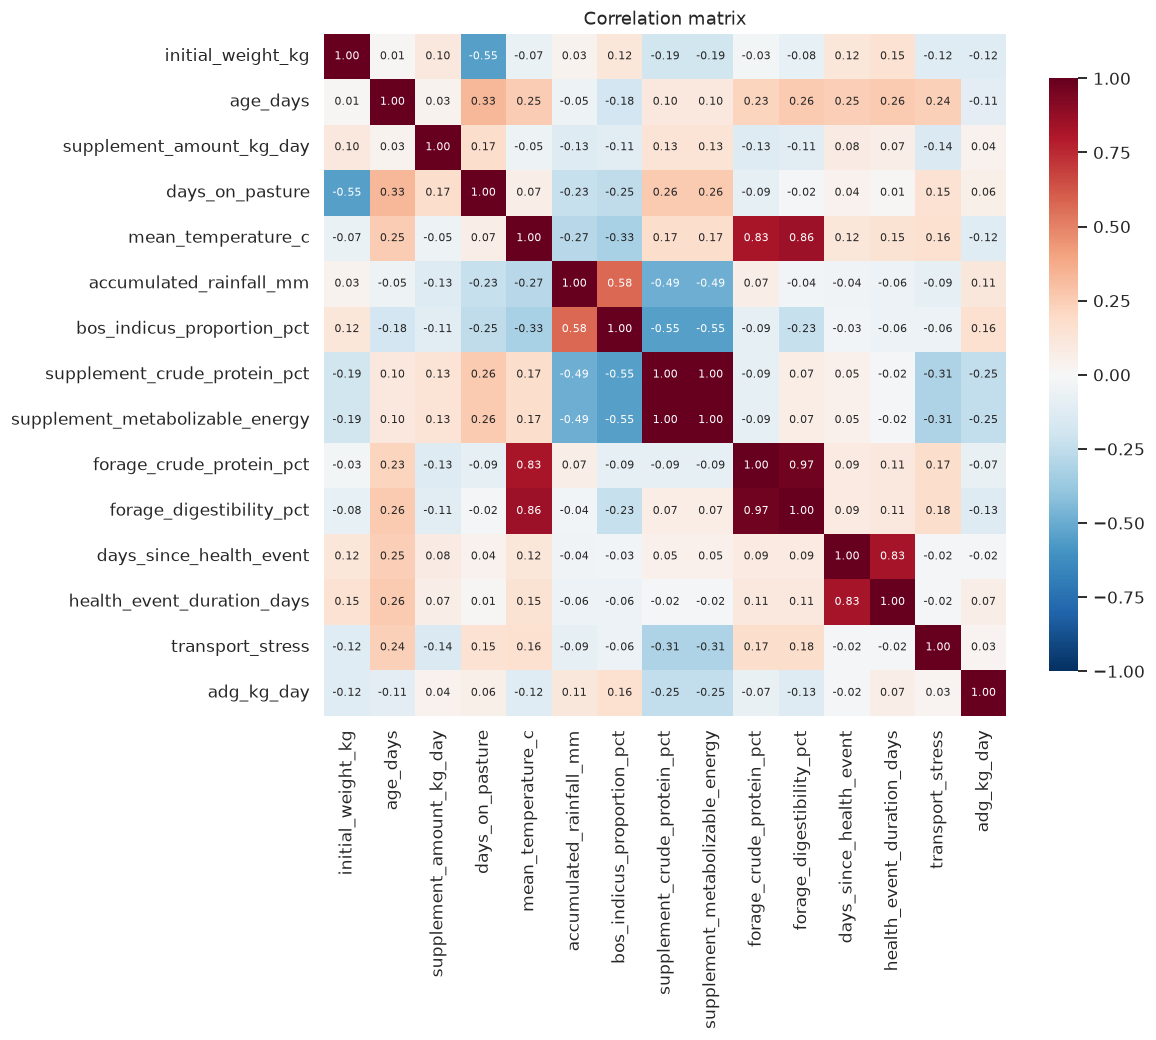

In [8]:
corr_cols = cont_cols + cat_cols + bin_cols + [TARGET]
corr = df[corr_cols].corr()
size = min(1 + 0.6 * len(corr_cols), 13)
fig, ax = plt.subplots(figsize=(size, size))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation matrix"); plt.show()

## 2.6. Correlation with the target

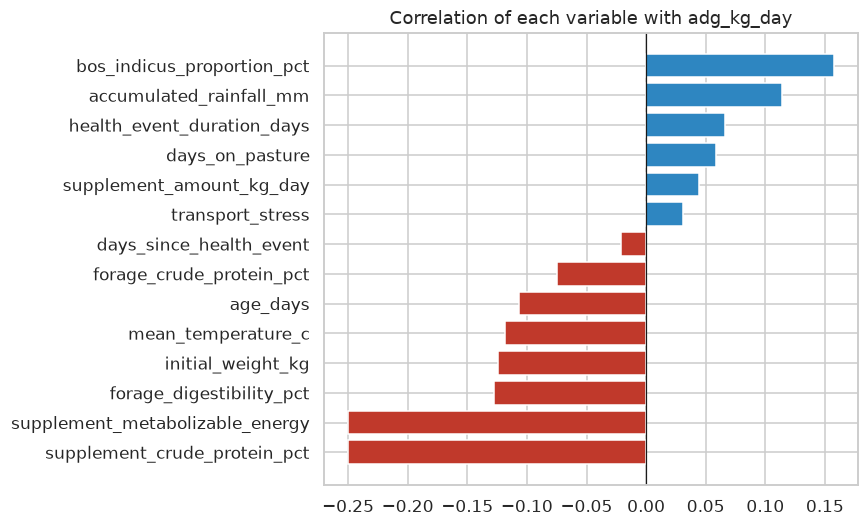

In [9]:
corr_target = corr[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(corr_target))))
colors = ["#c0392b" if v < 0 else "#2e86c1" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color="k", lw=.8)
ax.set_title(f"Correlation of each variable with {TARGET}")
plt.tight_layout(); plt.show()

if LEAKAGE in corr_target.index:
    print(f"WARNING: '{LEAKAGE}' is the denominator of the ADG formula "
          f"(spurious correlation / leakage). Keep it out of the model predictors.")

# 3. Data preparation

## 3.1. Select predictors (drop constants + leakage)

In [10]:
# Columns excluded from the model:
#  - constant columns (no variance -> no information)
#  - the leakage column (denominator of the ADG formula)
#  - the target itself
drop_cols = set(const_cols) | {LEAKAGE, TARGET}
feature_cols = [c for c in df.columns if c not in drop_cols]

# Numeric columns to standardize (continuous + low-cardinality numeric);
# binary 0/1 flags are kept as-is.
scale_cols = [c for c in (cont_cols + cat_cols) if c in feature_cols]
keep_cols  = [c for c in feature_cols if c not in scale_cols]

X = df[feature_cols].copy()
y = df[TARGET].copy()

print(f"Predictors ({len(feature_cols)}):", feature_cols)
print(f"To scale   ({len(scale_cols)}):", scale_cols)
print(f"Kept as-is ({len(keep_cols)}):", keep_cols)
print("Dropped    :", sorted(drop_cols))

Predictors (13): ['initial_weight_kg', 'age_days', 'bos_indicus_proportion_pct', 'supplement_amount_kg_day', 'supplement_crude_protein_pct', 'supplement_metabolizable_energy', 'forage_crude_protein_pct', 'forage_digestibility_pct', 'transport_stress', 'mean_temperature_c', 'accumulated_rainfall_mm', 'days_since_health_event', 'health_event_duration_days']
To scale   (12): ['initial_weight_kg', 'age_days', 'supplement_amount_kg_day', 'mean_temperature_c', 'accumulated_rainfall_mm', 'bos_indicus_proportion_pct', 'supplement_crude_protein_pct', 'supplement_metabolizable_energy', 'forage_crude_protein_pct', 'forage_digestibility_pct', 'days_since_health_event', 'health_event_duration_days']
Kept as-is (1): ['transport_stress']
Dropped    : ['adg_kg_day', 'days_on_pasture', 'paddock_rotation', 'recent_deworming', 'recent_vaccination', 'sex_male', 'supplementation_frequency_days_week']


## 3.2. Hold-out test split (85% dev / 15% test)

In [11]:
SEED = 42

# Reserve a held-out test set that no model sees during cross-validation.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED)

# reset index so KFold positional splits map cleanly back to rows
X_dev = X_dev.reset_index(drop=True);   y_dev = y_dev.reset_index(drop=True)
X_test = X_test.reset_index(drop=True); y_test = y_test.reset_index(drop=True)

print(f"Dev (for CV): {X_dev.shape[0]}   Held-out test: {X_test.shape[0]}")

Dev (for CV): 419   Held-out test: 75


# 4. Model definition and helpers

## 4.1. Network definition

In [12]:
class GainRegressor(nn.Module):
    """Dense net for ADG regression: Linear -> BatchNorm -> ReLU -> Dropout blocks."""
    def __init__(self, n_in, hidden=(128, 64, 32), p_drop=0.1, batchnorm=True):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers += [nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))       # linear output for regression
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

n_features = len(feature_cols)
print(f"Predictors: {n_features}")

Predictors: 13


## 4.2. Training & evaluation helpers

In [13]:
def fit_transformers(X_tr, y_tr):
    """Fit feature scaler + Yeo-Johnson target transform on training rows only."""
    x_sc = StandardScaler().fit(X_tr[scale_cols])
    y_tf = PowerTransformer(method="yeo-johnson").fit(y_tr.values.reshape(-1, 1))
    return x_sc, y_tf

def make_loader(X, y, x_sc, y_tf, batch_size=32, shuffle=False, drop_last=False):
    Xs = X.copy()
    Xs[scale_cols] = x_sc.transform(Xs[scale_cols])
    yt = y_tf.transform(y.values.reshape(-1, 1))           # target in transformed space
    ds = TensorDataset(torch.tensor(Xs.values, dtype=torch.float32),
                       torch.tensor(yt, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

def train_model(X_tr, y_tr, X_val, y_val, x_sc, y_tf,
                epochs=800, patience=40, lr=1e-3, verbose=False):
    """Train a fresh model with Huber loss + LR scheduling; early-stop on val."""
    # drop_last=True keeps BatchNorm from seeing a size-1 final batch
    train_loader = make_loader(X_tr, y_tr, x_sc, y_tf, shuffle=True, drop_last=True)
    val_loader   = make_loader(X_val, y_val, x_sc, y_tf)

    model = GainRegressor(n_features).to(device)
    criterion = nn.SmoothL1Loss()                          # Huber: robust to outliers
    optimizer = optim.Adam(model.parameters(), lr=lr)      # no weight decay
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10)

    history = {"train": [], "val": []}
    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(1, epochs + 1):
        model.train(); tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_loader.dataset)

        model.eval(); va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_loss += criterion(model(xb), yb).item() * xb.size(0)
        va_loss /= len(val_loader.dataset)
        scheduler.step(va_loss)

        history["train"].append(tr_loss); history["val"].append(va_loss)
        if va_loss < best_val - 1e-6:
            best_val, best_state, wait = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
        if verbose and (epoch == 1 or epoch % 20 == 0):
            print(f"  epoch {epoch:3d}  train={tr_loss:.5f}  val={va_loss:.5f}")

    model.load_state_dict(best_state)
    return model, history, best_val

def evaluate(model, X, y, x_sc, y_tf):
    """MAE / RMSE / R2 in original kg/day units (predictions inverse-transformed)."""
    Xs = X.copy(); Xs[scale_cols] = x_sc.transform(Xs[scale_cols])
    model.eval()
    with torch.no_grad():
        pred_t = model(torch.tensor(Xs.values, dtype=torch.float32).to(device)
                       ).cpu().numpy().reshape(-1, 1)
    pred = y_tf.inverse_transform(pred_t).ravel()          # back to kg/day
    yt = y.values
    return {"MAE":  mean_absolute_error(yt, pred),
            "RMSE": np.sqrt(mean_squared_error(yt, pred)),
            "R2":   r2_score(yt, pred)}

# 5. Cross-validation (10-fold)

## 5.1. Fold loop (inner validation for early stopping)

In [14]:
N_SPLITS = 10
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics = []
for i, (tr_idx, va_idx) in enumerate(kf.split(X_dev), 1):
    X_ftr, y_ftr = X_dev.iloc[tr_idx], y_dev.iloc[tr_idx]   # fold train
    X_fva, y_fva = X_dev.iloc[va_idx], y_dev.iloc[va_idx]   # fold validation (held out)

    # inner split of the fold-train for early stopping (never touches X_fva)
    X_in, X_es, y_in, y_es = train_test_split(
        X_ftr, y_ftr, test_size=0.15, random_state=SEED)

    x_sc, y_tf = fit_transformers(X_in, y_in)
    model, _, _ = train_model(X_in, y_in, X_es, y_es, x_sc, y_tf)
    m = evaluate(model, X_fva, y_fva, x_sc, y_tf)
    fold_metrics.append(m)
    print(f"fold {i:2d}  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R2={m['R2']:.4f}")

fold  1  MAE=0.0873  RMSE=0.1180  R2=0.2382


fold  2  MAE=0.1107  RMSE=0.1401  R2=0.2550


fold  3  MAE=0.0599  RMSE=0.0856  R2=0.0811


fold  4  MAE=0.0865  RMSE=0.1068  R2=0.3104


fold  5  MAE=0.0659  RMSE=0.0930  R2=0.5586


fold  6  MAE=0.0750  RMSE=0.1165  R2=0.2138


fold  7  MAE=0.0875  RMSE=0.1074  R2=-0.1856


fold  8  MAE=0.1275  RMSE=0.2532  R2=0.0297


fold  9  MAE=0.0953  RMSE=0.1286  R2=-0.1746


fold 10  MAE=0.0877  RMSE=0.1611  R2=0.2764


## 5.2. Cross-validation summary

In [15]:
cv = pd.DataFrame(fold_metrics)
print(cv.agg(["mean", "std"]).round(4).to_string())

# naive baseline for reference (predict the dev-set mean)
base = mean_absolute_error(y_dev, np.full(len(y_dev), y_dev.mean()))
print(f"\nBaseline MAE (predict mean): {base:.4f} kg/day")
print(f"CV mean MAE: {cv['MAE'].mean():.4f} +/- {cv['MAE'].std():.4f}")
print(f"CV mean R2 : {cv['R2'].mean():.4f} +/- {cv['R2'].std():.4f}")

         MAE    RMSE      R2
mean  0.0883  0.1310  0.1603
std   0.0200  0.0482  0.2280

Baseline MAE (predict mean): 0.0948 kg/day
CV mean MAE: 0.0883 +/- 0.0200
CV mean R2 : 0.1603 +/- 0.2280


# 6. Final model & test evaluation

## 6.1. Train on the full dev set

  epoch   1  train=0.32015  val=0.37845


  epoch  20  train=0.23846  val=0.29138


  epoch  40  train=0.23190  val=0.30007


  epoch  60  train=0.21048  val=0.29055
  epoch  80  train=0.21138  val=0.29705


  epoch 100  train=0.21907  val=0.29201


  epoch 120  train=0.22537  val=0.29650


  epoch 140  train=0.20508  val=0.29184
Best inner-val loss: 0.28828


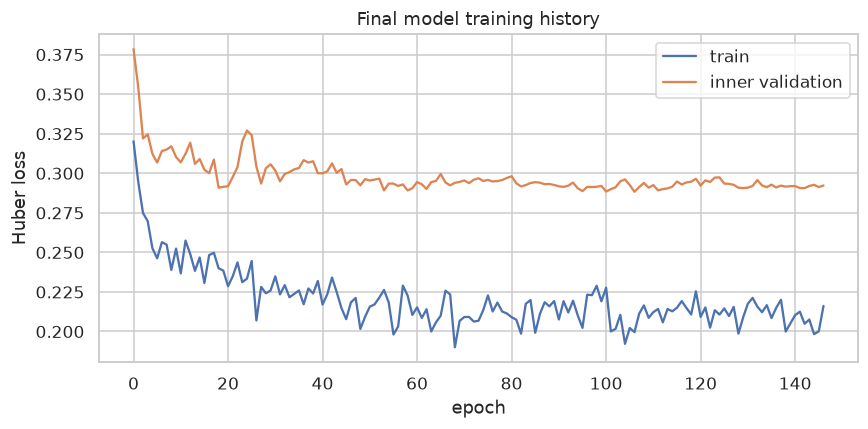

In [16]:
# final model: trained on all dev data, early-stopped on an inner validation split
X_in, X_es, y_in, y_es = train_test_split(
    X_dev, y_dev, test_size=0.15, random_state=SEED)

final_x_sc, final_y_tf = fit_transformers(X_in, y_in)
final_model, history, best_val = train_model(
    X_in, y_in, X_es, y_es, final_x_sc, final_y_tf, verbose=True)
print(f"Best inner-val loss: {best_val:.5f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train"], label="train")
ax.plot(history["val"], label="inner validation")
ax.set_xlabel("epoch"); ax.set_ylabel("Huber loss")
ax.set_title("Final model training history"); ax.legend()
plt.tight_layout(); plt.show()

## 6.2. Held-out test metrics

In [17]:
test_metrics = evaluate(final_model, X_test, y_test, final_x_sc, final_y_tf)
base_mae = mean_absolute_error(y_test, np.full(len(y_test), y_dev.mean()))

print(f"Test MAE : {test_metrics['MAE']:.4f} kg/day")
print(f"Test RMSE: {test_metrics['RMSE']:.4f} kg/day")
print(f"Test R2  : {test_metrics['R2']:.4f}")
print(f"Baseline MAE (predict mean): {base_mae:.4f} kg/day")

Test MAE : 0.1108 kg/day
Test RMSE: 0.2126 kg/day
Test R2  : 0.2228
Baseline MAE (predict mean): 0.1205 kg/day


## 6.3. Predicted vs actual

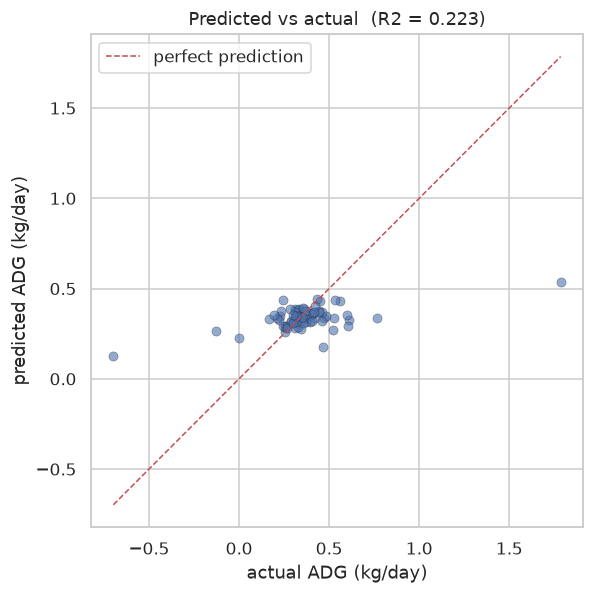

In [18]:
final_model.eval()
Xte = X_test.copy(); Xte[scale_cols] = final_x_sc.transform(Xte[scale_cols])
with torch.no_grad():
    pred_t = final_model(torch.tensor(Xte.values, dtype=torch.float32).to(device)
                         ).cpu().numpy().reshape(-1, 1)
y_pred = final_y_tf.inverse_transform(pred_t).ravel()
y_true = y_test.values

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_pred, alpha=0.6, edgecolor="k", linewidth=.3)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
ax.set_xlabel("actual ADG (kg/day)"); ax.set_ylabel("predicted ADG (kg/day)")
ax.set_title(f"Predicted vs actual  (R2 = {test_metrics['R2']:.3f})")
ax.legend(); plt.tight_layout(); plt.show()

## 6.4. Save model

In [19]:
os.makedirs("models", exist_ok=True)
ckpt = {
    "model_state":  final_model.state_dict(),
    "scaler_mean":  final_x_sc.mean_,
    "scaler_scale": final_x_sc.scale_,
    "y_lambdas":    final_y_tf.lambdas_,
    "feature_cols": feature_cols,
    "scale_cols":   scale_cols,
    "cv_metrics":   cv.to_dict(orient="list"),
}
torch.save(ckpt, "models/model_adg_dnn.pth")
print("Saved to models/model_adg_dnn.pth")

Saved to models/model_adg_dnn.pth
